In [1]:
# 设置随机种子，使实验结果可重复
import random
import torch
import torch.nn as nn
import numpy as np

seed = 42

random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.use_deterministic_algorithms(True)
np.random.seed(seed)

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

# 加载糖尿病数据集
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# 创建DataFrame便于查看
feature_names = diabetes.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y


In [3]:
# 查看数据基本信息
print(f"特征字段: {diabetes.feature_names}")
print(f"样本数: {len(df)}")
print(f"特征数: {X.shape[1]}")
print(f"目标变量范围: [{y.min():.2f}, {y.max():.2f}]")
print(f"目标变量均值: {y.mean():.2f}, 标准差: {y.std():.2f}")

# 显示前5行数据
print("\n数据示例（前5行）:")
df.head()

特征字段: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
样本数: 442
特征数: 10
目标变量范围: [25.00, 346.00]
目标变量均值: 152.13, 标准差: 77.01

数据示例（前5行）:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 特征描述

所有特征均已进行标准化处理：
- `age`: 年龄
- `sex`: 性别  
- `bmi`: 身体质量指数
- `bp`: 平均血压
- `s1~s6`: 六种血清含量指标（总胆固醇、低密度脂蛋白、高密度脂蛋白、总胆固醇/高密度脂蛋白比值、血清谷丙转氨酶、血糖）

目标变量为连续值，表示糖尿病疾病进展指标（定量测量一年后的疾病进展）。

In [4]:
# 数据分割示例
from sklearn.model_selection import train_test_split

# 按4:1划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

训练集大小: 353
测试集大小: 89


In [5]:
# 事实上数据并没有被标准化，这里重新进行标准化处理

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [6]:
# 准备 5-fold 交叉验证

from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X_train))
print(f"总训练样本数: {X_train.shape[0]}")
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {i+1}: 训练样本数={len(train_idx)}, 验证样本数={len(val_idx)}")

总训练样本数: 353
Fold 1: 训练样本数=282, 验证样本数=71
Fold 2: 训练样本数=282, 验证样本数=71
Fold 3: 训练样本数=282, 验证样本数=71
Fold 4: 训练样本数=283, 验证样本数=70
Fold 5: 训练样本数=283, 验证样本数=70


In [7]:
import importlib
import mlp
import matplotlib.pyplot as plt
import numpy as np

mlp = importlib.reload(mlp)

def valid_result(
        num_hidden_layers=0,
        hidden_layer_sizes=[],
        activation='none',
        lr=1e-2,
        epochs=100,
    ):

    cv_results = mlp.k_fold_cross_validate(
        X=X_train,
        y=y_train,
        model_factory_kwargs={
            'num_hidden_layers': num_hidden_layers,
            'hidden_layer_sizes': hidden_layer_sizes,
            'activation': activation,
        },
        optimizer_factory_kwargs={
            'lr': lr,
        },
        num_folds=5,
        num_epochs=epochs,
        batch_size=32,
    )

    # 聚合平均训练，验证损失
    
    train_losses = np.array([result['train_losses'] for result in cv_results]).mean(axis=0)
    val_losses = np.array([result['val_losses'] for result in cv_results]).mean(axis=0)
    best_epoch = np.argmin(val_losses)
    best_train_loss = train_losses[best_epoch]
    best_val_loss = val_losses[best_epoch]

    results = {
        'lr': lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_train_loss': best_train_loss,
        'best_val_loss': best_val_loss,
    } 

    return results

In [8]:
baseline = valid_result(2, [16, 16], 'relu', 1e-3, 500)
baseline2 = valid_result(2, [16, 16], 'relu', 1e-2, 500)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
def plot_loss_curve(model, start=0, end=-1, y_range=None):
    plt.plot(model['train_losses'][start:end], label=f'Baseline Train Loss (lr={model["lr"]:.1e})')
    plt.plot(model['val_losses'][start:end], label=f'Baseline Val Loss (lr={model["lr"]:.1e})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    if y_range is not None:
        plt.ylim(y_range)
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

In [10]:
shallow = valid_result(1, [16], 'relu', 1e-2, 500)
deep = valid_result(3, [16, 16, 16], 'relu', 1e-2, 500)

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

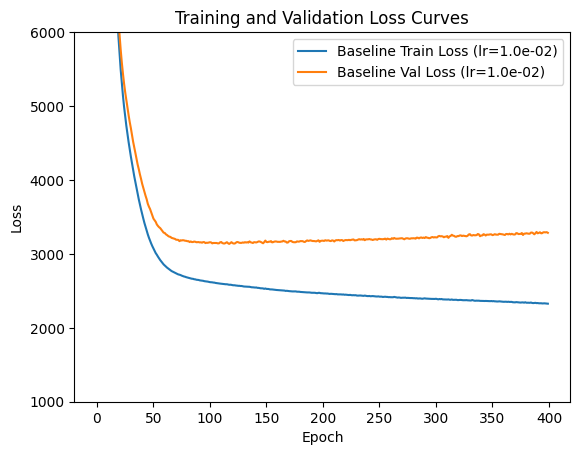

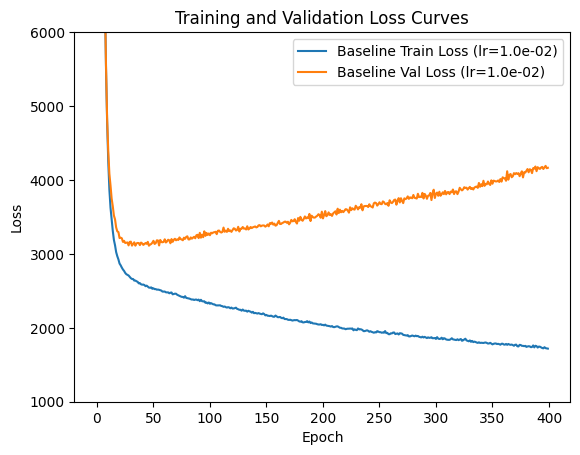

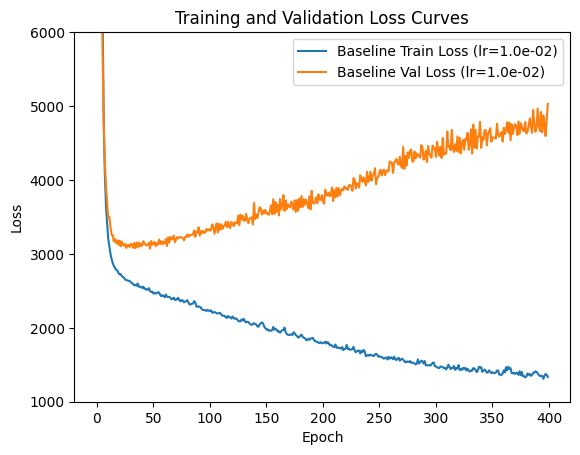

Best epochs - Shallow: 117, Baseline2: 46, Deep: 47
Best losses - Shallow: 3134.77, Baseline2: 3110.81, Deep: 3071.66


In [11]:
shallow['best_epoch'], deep['best_epoch']
plot_loss_curve(shallow, 0, 400, (1000, 6000))
plot_loss_curve(baseline2, 0, 400, (1000, 6000))
plot_loss_curve(deep, 0, 400, (1000, 6000))
print(f"Best epochs - Shallow: {shallow['best_epoch']}, Baseline2: {baseline2['best_epoch']}, Deep: {deep['best_epoch']}")
print(f"Best losses - Shallow: {shallow['best_val_loss']:.2f}, Baseline2: {baseline2['best_val_loss']:.2f}, Deep: {deep['best_val_loss']:.2f}")

In [ ]:
lr1 = valid_result(2, [16, 16], 'relu', 1e-1, 500)
lr4 = valid_result(2, [16, 16], 'relu', 1e-4, 2000)
print(f"Best epochs - LR1: {lr1['best_epoch']}, LR2: {baseline2['best_epoch']}, LR3: {baseline['best_epoch']}, LR4: {lr4['best_epoch']}")
print(f"Best losses - LR1: {lr1['best_val_loss']:.2f}, LR2: {baseline2['best_val_loss']:.2f}, LR3: {baseline['best_val_loss']:.2f}, LR4: {lr4['best_val_loss']:.2f}")

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Best epochs - LR1: 21, LR2: 46, LR3: 280, LR4: 499
Best losses - LR1: 3151.40, LR2: 3110.81, LR3: 3079.21, LR4: 8603.17


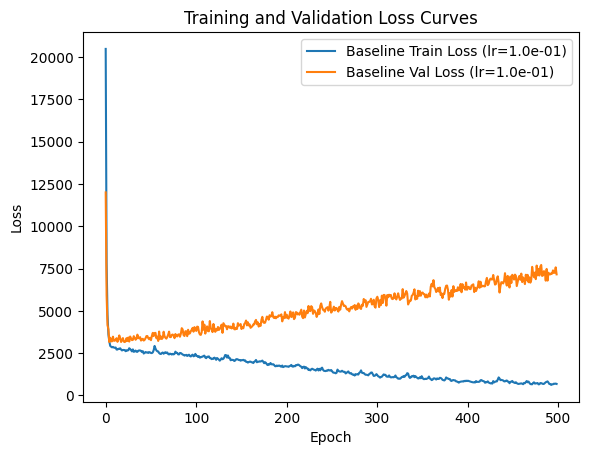

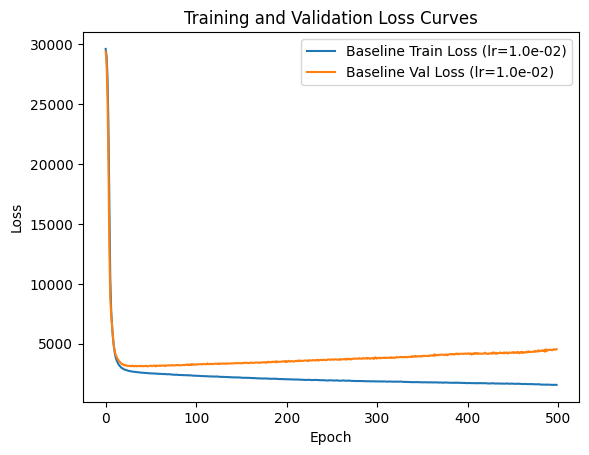

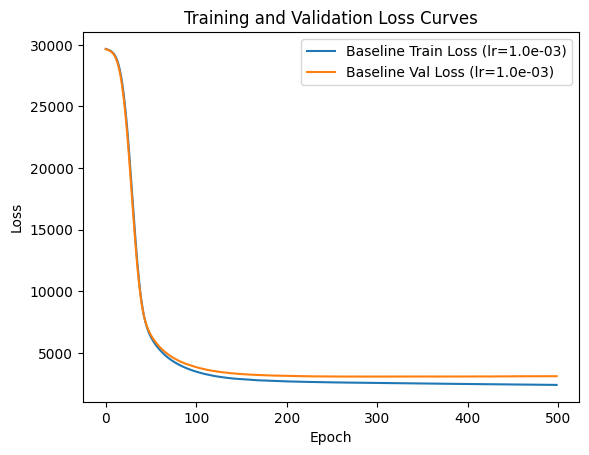

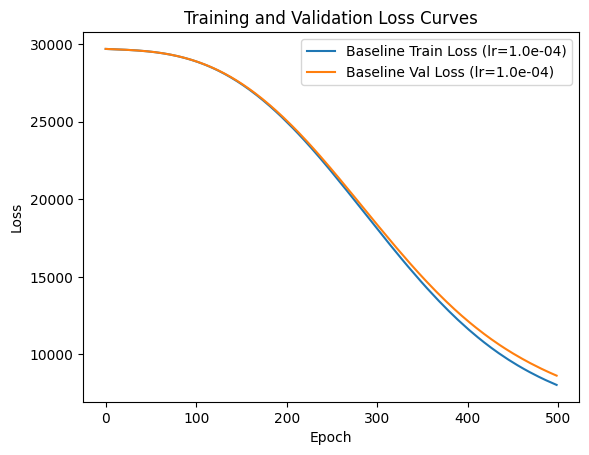

In [13]:
plot_loss_curve(lr1)
plot_loss_curve(baseline2)
plot_loss_curve(baseline)
plot_loss_curve(lr4)

In [14]:
sig = valid_result(2, [16, 16], 'sigmoid', 1e-2, 500)
tanh = valid_result(2, [16, 16], 'tanh', 1e-2, 500)
lea = valid_result(2, [16, 16], 'leaky_relu', 1e-2, 500)
swi = valid_result(2, [16, 16], 'swish', 1e-2, 500)
print(f"Best epochs - Sigmoid: {sig['best_epoch']}, Tanh: {tanh['best_epoch']}, ReLU: {baseline2['best_epoch']}, Leaky ReLU: {lea['best_epoch']}, Swish: {swi['best_epoch']}")
print(f"Best losses - Sigmoid: {sig['best_val_loss']:.2f}, Tanh: {tanh['best_val_loss']:.2f}, ReLU: {baseline2['best_val_loss']:.2f}, Leaky ReLU: {lea['best_val_loss']:.2f}, Swish: {swi['best_val_loss']:.2f}")

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Fold:   0%|          | 0/5 [00:00<?, ?it/s]

Best epochs - Sigmoid: 251, Tanh: 293, ReLU: 46, Leaky ReLU: 27, Swish: 40
Best losses - Sigmoid: 4120.10, Tanh: 4248.92, ReLU: 3110.81, Leaky ReLU: 3174.95, Swish: 3217.72


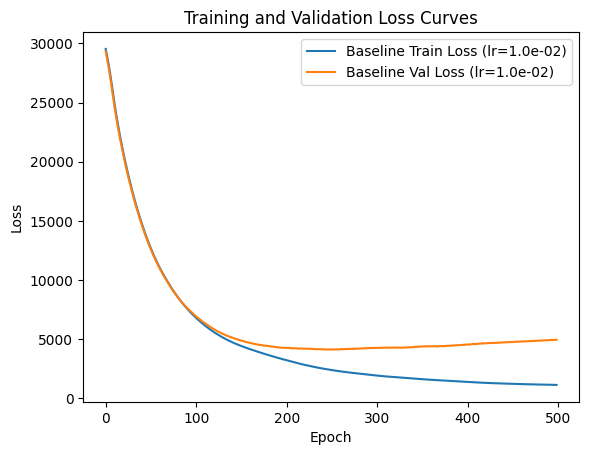

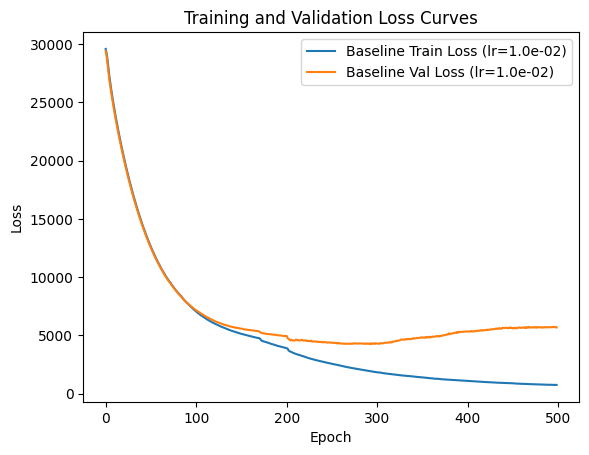

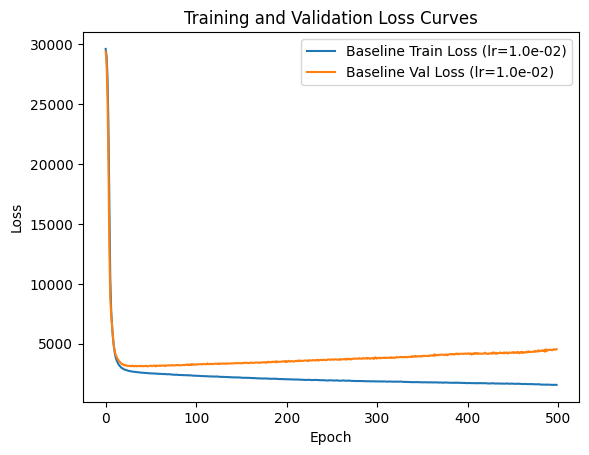

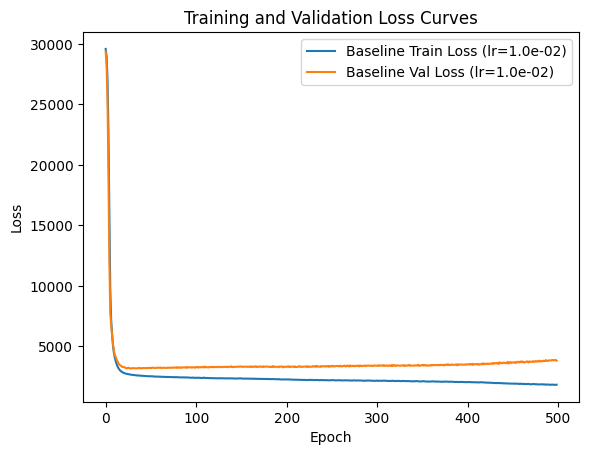

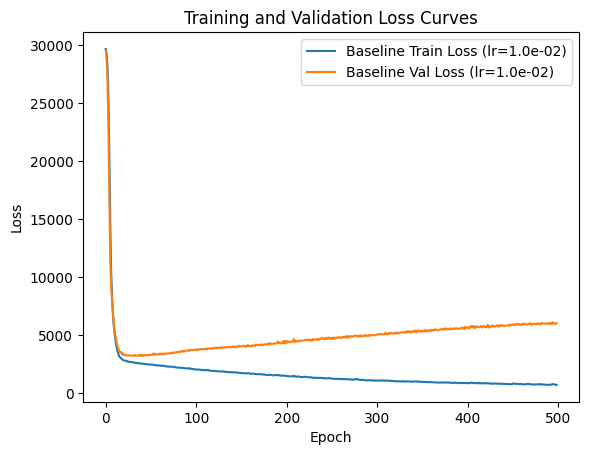

In [15]:
plot_loss_curve(sig)
plot_loss_curve(tanh)
plot_loss_curve(baseline2)
plot_loss_curve(lea)
plot_loss_curve(swi)